In [83]:
#from_python_library_
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#from_sklearn_
from sklearn.preprocessing import LabelEncoder, StandardScaler #converting_all_the_categorical__into_numbers and using_compress_numbers_to(0,1)_using_Standardscaler_
from sklearn.model_selection import train_test_split #for_training_and_testing_
from sklearn.linear_model import Perceptron # for_perceptron_
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix #for_the_evaluation_calucation_and_result_


#from_tensorflow_
import tensorflow as tf
from tensorflow import keras
from keras import Sequential #I want to build my neural network by adding layers one after another.
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, Dropout
#Dense = (🧠Decision Maker)--> Uses learned features to make predictions
#Conv2D = (🔍Feature Finder)--> Finds edges, shapes, patterns in images
#Flatten = (🔄Converter)--> Converts 2D/3D feature maps → 1D vector
#MaxPooling2D = (📉Size Reducer)--> Reduces image/feature-map size while keeping important features
#Dropout = (🛡️Protection)--> Randomly drops neurons during training to reduce overfitting


from keras.utils import to_categorical #It converts class labels (numbers) into One-Hot Encoded vectors.

In [84]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [85]:
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [86]:
# Flatten images: 28 × 28 = 784
X_train_flat = X_train.reshape(X_train.shape[0], 784)
X_test_flat = X_test.reshape(X_test.shape[0], 784)

# Convert to DataFrame
train_df = pd.DataFrame(X_train_flat)
test_df = pd.DataFrame(X_test_flat)

# Add label column
train_df["label"] = y_train
test_df["label"] = y_test

# Save as CSV
train_df.to_csv("mnist_train.csv", index=False)
test_df.to_csv("mnist_test.csv", index=False)
print("CSV files created!")

CSV files created!


In [87]:
train_df.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,label
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,252,42,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4


In [88]:
test_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767,768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,label
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4


In [89]:
train_df.shape

(60000, 785)

In [90]:
train_df.columns

Index([      0,       1,       2,       3,       4,       5,       6,       7,
             8,       9,
       ...
           775,     776,     777,     778,     779,     780,     781,     782,
           783, 'label'],
      dtype='object', length=785)

In [91]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, 0 to label
dtypes: uint8(785)
memory usage: 44.9 MB


In [92]:
train_df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
780,0
781,0
782,0
783,0


In [93]:
#Preprocessing the data:
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values
X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values


#Normalize pixel values: 0–255 → 0–1
X_train = X_train / 255.0
X_test = X_test / 255.0

**i have did Reshaping**

In [94]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [95]:
X_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [96]:
X_test_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [97]:
#num into categorical like onehotencoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

In [98]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [99]:
y_test

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

***__Perceptron_____***

In [100]:
perceptron = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(10, activation='softmax')
])

In [101]:
perceptron.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
perceptron.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

In [102]:
history = perceptron.fit(X_train_img, y_train,validation_data=(X_test_img, y_test),epochs=10, batch_size=32, verbose = 1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8112 - loss: 0.7812 - val_accuracy: 0.8771 - val_loss: 0.4821
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8796 - loss: 0.4587 - val_accuracy: 0.8938 - val_loss: 0.4007
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8906 - loss: 0.4048 - val_accuracy: 0.9003 - val_loss: 0.3674
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8967 - loss: 0.3777 - val_accuracy: 0.9046 - val_loss: 0.3483
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9010 - loss: 0.3607 - val_accuracy: 0.9082 - val_loss: 0.3361
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9040 - loss: 0.3487 - val_accuracy: 0.9110 - val_loss: 0.3264
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9060 - loss: 0.3396 - val_accuracy: 0.9123 - val_loss: 0.3192
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9074 - loss: 0.3324 - 

In [103]:
from sklearn.metrics import accuracy_score, classification_report

# Prediction
y_pred_prob = perceptron.predict(X_test_img)

# Convert probabilities → class labels
y_pred = y_pred_prob.argmax(axis=1)

# Convert one-hot y_test → class labels
y_true = y_test.argmax(axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_true, y_pred))

# Classification Report
print(classification_report(y_true, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.9154
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.96      0.97      0.97      1135
           2       0.92      0.88      0.90      1032
           3       0.90      0.90      0.90      1010
           4       0.91      0.92      0.92       982
           5       0.90      0.86      0.88       892
           6       0.92      0.95      0.94       958
           7       0.93      0.91      0.92      1028
           8       0.87      0.88      0.87       974
           9       0.89      0.89      0.89      1009

    accuracy                           0.92     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.92      0.92      0.92     10000



In [104]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 0.9102833271026611
Final Validation Accuracy: 0.9154000282287598


***ANN___***

In [105]:
annmodel = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'), #1st hidden layer
    Dense(64, activation='relu'), #2nd hidden layer
    Dense(10, activation='softmax') #3rd hidden layer
])

annmodel.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
annmodel.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [106]:
history = perceptron.fit(X_train_img,
                         y_train,
                         validation_data=(X_test_img, y_test),
                         epochs=10, batch_size=32, verbose = 1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9118 - loss: 0.3173 - val_accuracy: 0.9155 - val_loss: 0.3023
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9130 - loss: 0.3135 - val_accuracy: 0.9166 - val_loss: 0.3001
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9137 - loss: 0.3104 - val_accuracy: 0.9171 - val_loss: 0.2981
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9146 - loss: 0.3076 - val_accuracy: 0.9174 - val_loss: 0.2957
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9151 - loss: 0.3049 - val_accuracy: 0.9180 - val_loss: 0.2939
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9157 - loss: 0.3026 - val_accuracy: 0.9174 - val_loss: 0.2921
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9163 - loss: 0.3004 - val_accuracy: 0.9182 - val_loss: 0.2901
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9168 - loss: 0.2985 - 

In [107]:
# Best validation accuracy
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val_accuracy = np.max(history.history['val_accuracy'])

print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_accuracy)

Best Epoch: 8
Best Validation Accuracy: 0.9194999933242798


In [108]:
# Prediction
y_pred_prob = annmodel.predict(X_test_img)

# Convert probabilities → class labels
y_pred = y_pred_prob.argmax(axis=1)

# Convert one-hot y_test → class labels
y_true = y_test.argmax(axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_true, y_pred))

# Classification Report
print(classification_report(y_true, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.0956
              precision    recall  f1-score   support

           0       0.02      0.06      0.03       980
           1       0.00      0.00      0.00      1135
           2       0.00      0.00      0.00      1032
           3       0.15      0.23      0.18      1010
           4       0.11      0.03      0.05       982
           5       0.27      0.03      0.05       892
           6       0.12      0.65      0.20       958
           7       0.00      0.00      0.00      1028
           8       0.00      0.00      0.00       974
           9       0.02      0.00      0.00      1009

    accuracy                           0.10     10000
   macro avg       0.07      0.10      0.05     10000
weighted avg       0.07      0.10      0.05     10000



In [109]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 0.9178333282470703
Final Validation Accuracy: 0.9193000197410583


In [123]:
acc_ann = annmodel.evaluate(X_test_img, y_test)[1]
print("CNN Accuracy:", acc_ann)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0956 - loss: 2.3659
CNN Accuracy: 0.09560000151395798


***CNN_***

In [113]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [114]:
cnnmodel = Sequential([
  Conv2D(32, kernel_size = (3,3), padding = 'valid', activation= 'relu', input_shape= (28,28,1)),
  MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'),
  Conv2D(64, kernel_size = (3,3), padding = 'valid', activation = 'relu'),
  MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'),
  Flatten(),
  Dense(128, activation = 'relu'),
  Dropout(0.5),
  Dense(10, activation = 'softmax')
])

In [116]:
cnnmodel.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnnmodel.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [117]:
history = cnnmodel.fit(X_train_cnn,
                         y_train,
                         validation_data=(X_test_cnn, y_test),
                         epochs=10, batch_size=32, verbose = 1)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.9375 - loss: 0.2031 - val_accuracy: 0.9857 - val_loss: 0.0423
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 74s 39ms/step - accuracy: 0.9771 - loss: 0.0783 - val_accuracy: 0.9895 - val_loss: 0.0323
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 96s 47ms/step - accuracy: 0.9829 - loss: 0.0581 - val_accuracy: 0.9900 - val_loss: 0.0293
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 130s 41ms/step - accuracy: 0.9857 - loss: 0.0457 - val_accuracy: 0.9899 - val_loss: 0.0322
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.9878 - loss: 0.0386 - val_accuracy: 0.9920 - val_loss: 0.0269
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 41ms/step - accuracy: 0.9892 - loss: 0.0333 - val_accuracy: 0.9932 - val_loss: 0.0244
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - accuracy: 0.9915 - loss: 0.0278 - val_accuracy: 0.9911 - val_loss: 0.0312
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 46ms/step - accuracy: 0.9926 

In [119]:
# Best validation accuracy
best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val_accuracy = np.max(history.history['val_accuracy'])

print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_accuracy)

Best Epoch: 6
Best Validation Accuracy: 0.9932000041007996


In [125]:
acc_cnn = cnnmodel.evaluate(X_test_cnn, y_test)[1]
print("CNN Accuracy:", acc_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9911 - loss: 0.0294
CNN Accuracy: 0.991100013256073


### **Perceptron Model Evaluation Visuals**

In [135]:
# Re-train Perceptron model to capture its history for plotting
perceptron = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(10, activation='softmax')
])
perceptron.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history_perceptron = perceptron.fit(X_train_img, y_train, validation_data=(X_test_img, y_test), epochs=10, batch_size=32, verbose=0)

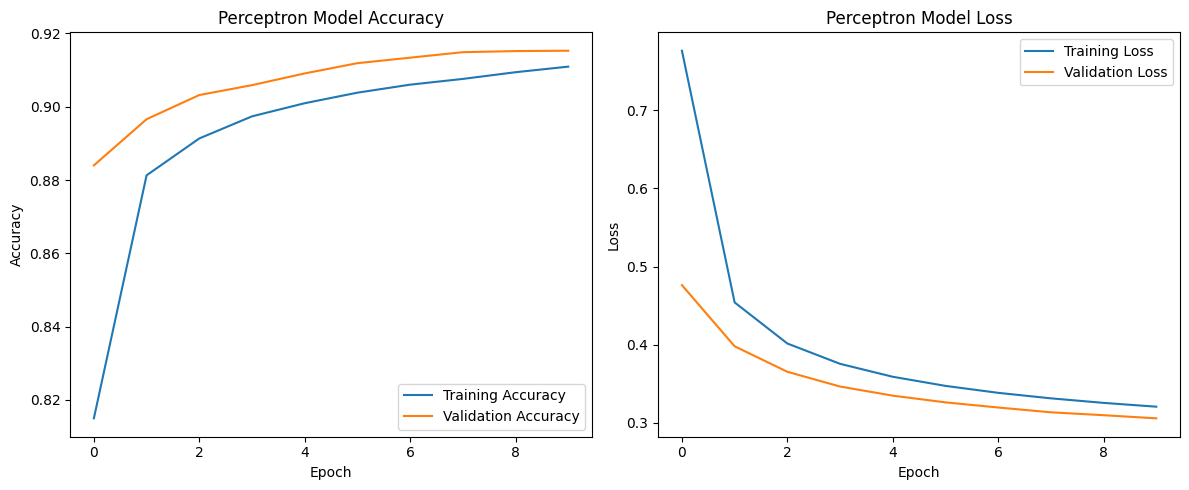

In [136]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_perceptron.history['accuracy'], label='Training Accuracy')
plt.plot(history_perceptron.history['val_accuracy'], label='Validation Accuracy')
plt.title('Perceptron Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_perceptron.history['loss'], label='Training Loss')
plt.plot(history_perceptron.history['val_loss'], label='Validation Loss')
plt.title('Perceptron Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


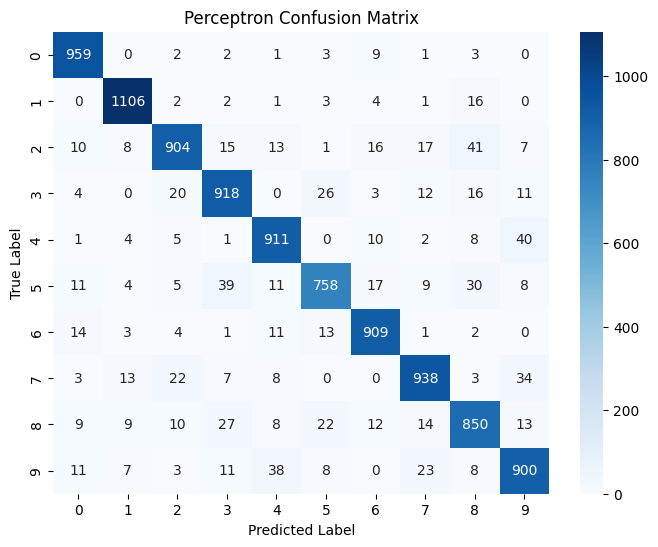

In [137]:
y_pred_perceptron = perceptron.predict(X_test_img).argmax(axis=1)
y_true_labels = y_test.argmax(axis=1)

cm_perceptron = confusion_matrix(y_true_labels, y_pred_perceptron)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_perceptron, annot=True, fmt='d', cmap='Blues')
plt.title('Perceptron Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### **ANN Model Evaluation Visuals**

In [138]:
# Re-train ANN model to capture its history for plotting
annmodel = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
annmodel.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_ann = annmodel.fit(X_train_img, y_train, validation_data=(X_test_img, y_test), epochs=10, batch_size=32, verbose=0)

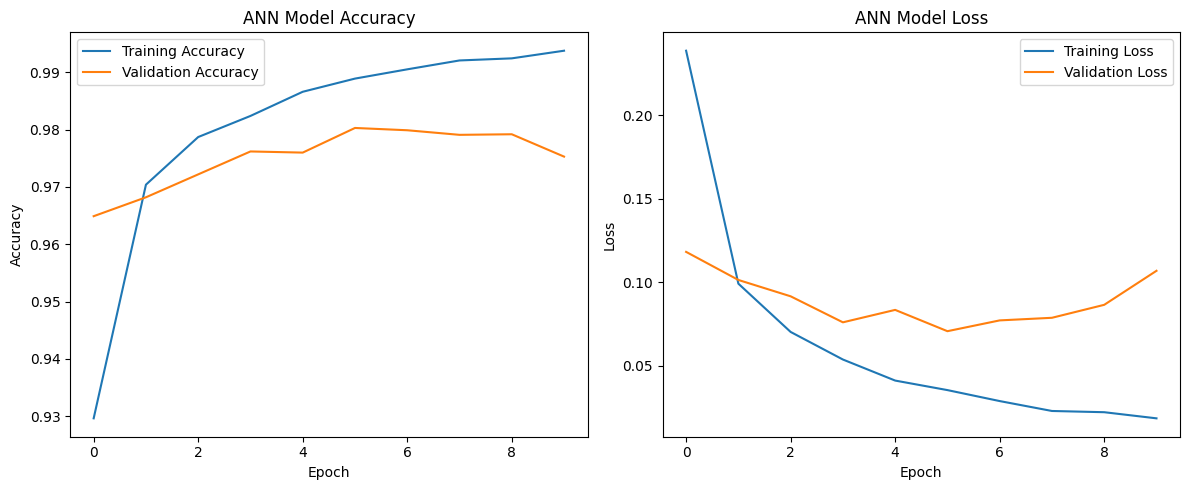

In [139]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_ann.history['accuracy'], label='Training Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ann.history['loss'], label='Training Loss')
plt.plot(history_ann.history['val_loss'], label='Validation Loss')
plt.title('ANN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


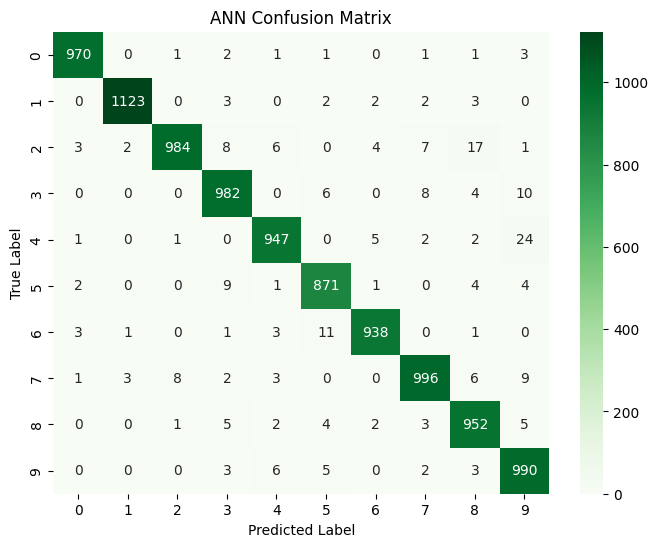

In [140]:
y_pred_ann = annmodel.predict(X_test_img).argmax(axis=1)
cm_ann = confusion_matrix(y_true_labels, y_pred_ann)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Greens')
plt.title('ANN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### **CNN Model Evaluation Visuals**

In [141]:
# Re-train CNN model to capture its history for plotting
cnnmodel = Sequential([
  Conv2D(32, kernel_size = (3,3), padding = 'valid', activation= 'relu', input_shape= (28,28,1)),
  MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'),
  Conv2D(64, kernel_size = (3,3), padding = 'valid', activation = 'relu'),
  MaxPooling2D(pool_size = (2,2), strides = 2, padding = 'valid'),
  Flatten(),
  Dense(128, activation = 'relu'),
  Dropout(0.5),
  Dense(10, activation = 'softmax')
])
cnnmodel.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_cnn = cnnmodel.fit(X_train_cnn, y_train, validation_data=(X_test_cnn, y_test), epochs=10, batch_size=32, verbose=0)

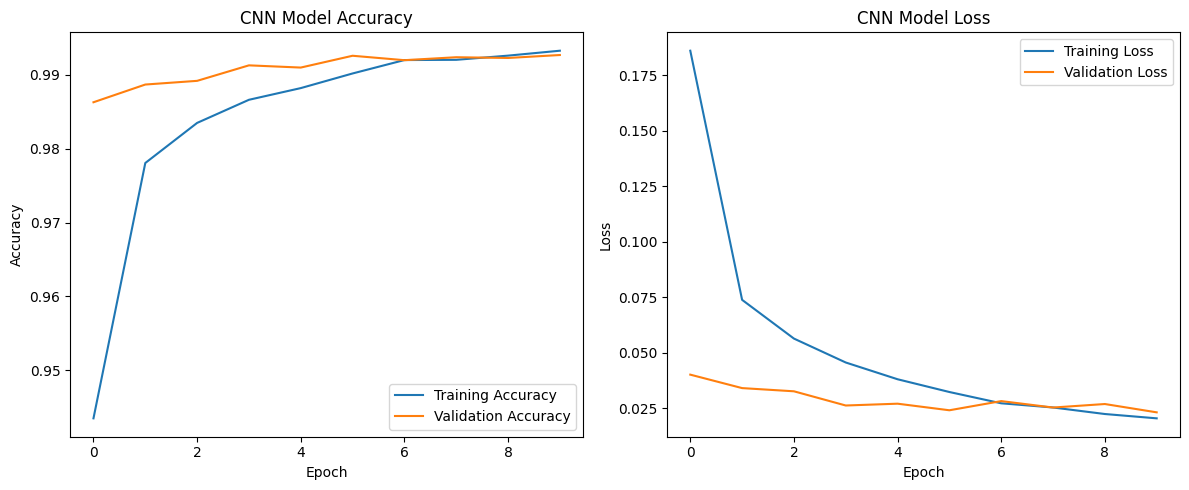

In [142]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


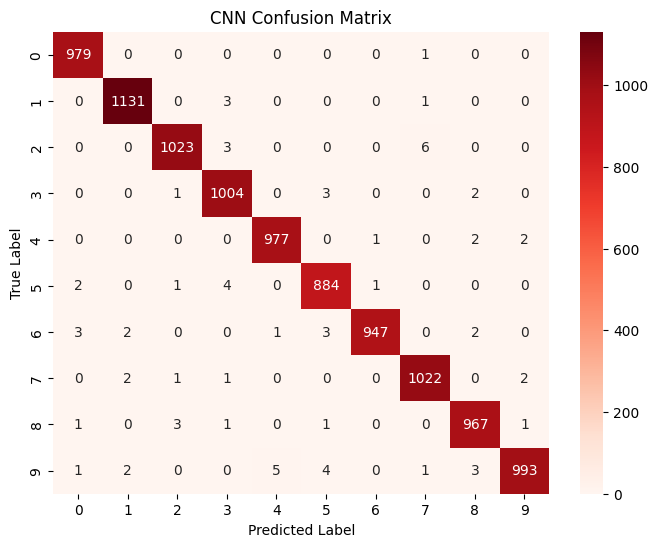

In [143]:
y_pred_cnn = cnnmodel.predict(X_test_cnn).argmax(axis=1)
cm_cnn = confusion_matrix(y_true_labels, y_pred_cnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Reds')
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### **Overall Model Comparison**

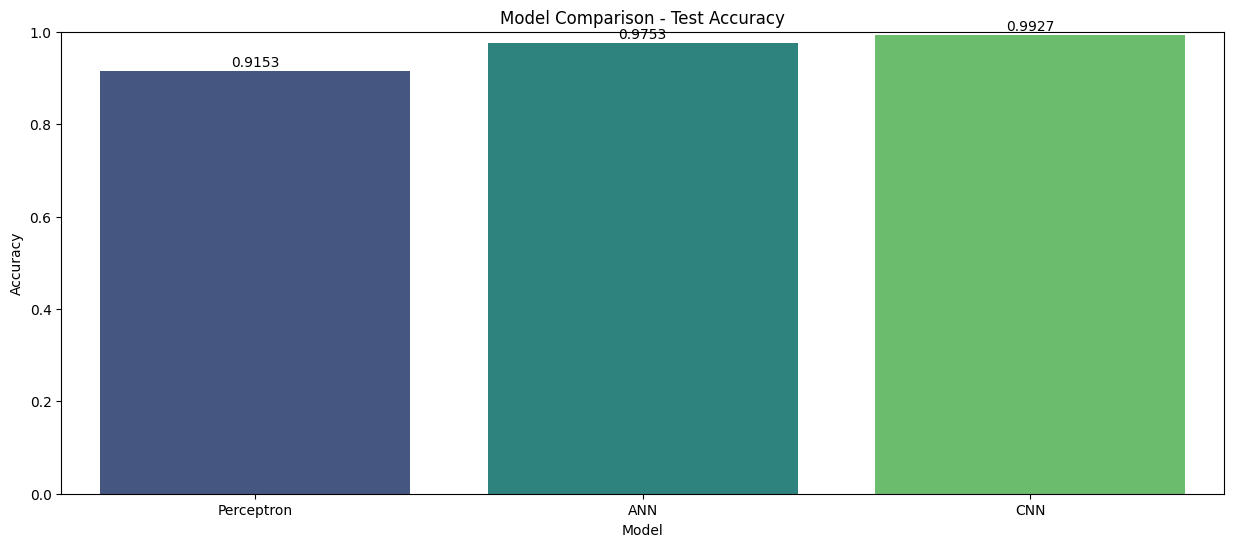


--- Final Model Accuracies ---
Perceptron: 0.9153
ANN: 0.9753
CNN: 0.9927


In [149]:
perceptron_accuracy = perceptron.evaluate(X_test_img, y_test, verbose=0)[1]
ann_accuracy = annmodel.evaluate(X_test_img, y_test, verbose=0)[1]
cnn_accuracy = cnnmodel.evaluate(X_test_cnn, y_test, verbose=0)[1]

models = ['Perceptron', 'ANN', 'CNN']
accuracies = [perceptron_accuracy, ann_accuracy, cnn_accuracy]

plt.figure(figsize=(15, 6))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Model Comparison - Test Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

for index, value in enumerate(accuracies):
    plt.text(index, value + 0.01, f'{value:.4f}', ha='center')

plt.show()

print("\n--- Final Model Accuracies ---")
for model, acc in zip(models, accuracies):
    print(f'{model}: {acc:.4f}')

### **Sample Image Predictions**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


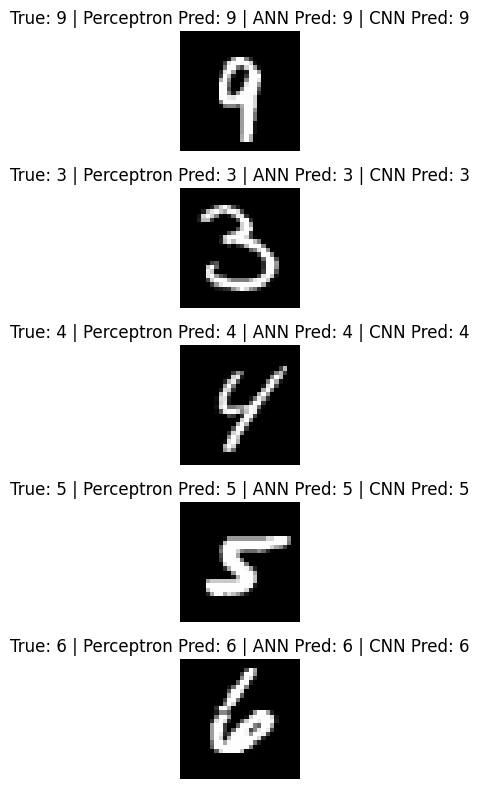

In [156]:
num_samples = 5  # Number of samples to display
random_indices = np.random.choice(len(X_test_img), num_samples, replace=False)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(random_indices):
    # Original Image
    img = X_test_img[idx]
    true_label = y_true_labels[idx]

    # Get predictions from each model
    pred_perceptron = perceptron.predict(img.reshape(1, 28, 28)).argmax(axis=1)[0]
    pred_ann = annmodel.predict(img.reshape(1, 28, 28)).argmax(axis=1)[0]
    pred_cnn = cnnmodel.predict(X_test_cnn[idx].reshape(1, 28, 28, 1)).argmax(axis=1)[0]

    plt.subplot(num_samples, 1, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {true_label} | Perceptron Pred: {pred_perceptron} | ANN Pred: {pred_ann} | CNN Pred: {pred_cnn}")
    plt.axis('off')

plt.tight_layout()
plt.show()